## 0. Datos: carga

In [29]:
import pyreadstat
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ruta = "/Users/haeidyvilcapazahuaman/Documents/GitHub/Maestria_proyecto/data/raw/966-Modulo02/Enaho01-2024-200.sav"

base, meta = pyreadstat.read_sav(ruta)

print(base.head())
print(base.shape)

    AÑO MES CONGLOME VIVIENDA HOGAR CODPERSO  UBIGEO  DOMINIO  ESTRATO  \
0  2024  09   010651      013    11       01  150509      2.0      4.0   
1  2024  09   010651      013    11       02  150509      2.0      4.0   
2  2024  09   010651      013    11       03  150509      2.0      4.0   
3  2024  09   010651      013    11       04  150509      2.0      4.0   
4  2024  09   010651      026    11       01  150509      2.0      4.0   

               P201P  ...  OCUPAC_R3  OCUPAC_R4  RAMA_R3  RAMA_R4  CODTAREA  \
0  20240106510131101  ...        NaN        NaN      NaN      NaN             
1  20240106510131102  ...        NaN        NaN      NaN      NaN             
2  20240106510131103  ...        NaN        NaN      NaN      NaN             
3  20240106510131104  ...        NaN        NaN      NaN      NaN             
4  20240106510261101  ...        NaN        NaN      NaN      NaN             

   CODTIEMPO  TICUEST01    FACPOB07  NCONGLOME  SUB_CONGLOME  
0                

In [30]:
# Crear una tabla con los nombres y las etiquetas de las variables
variables = pd.DataFrame({
    "Variable": meta.column_names,
    "Etiqueta": [
        meta.column_names_to_labels.get(var, "")
        for var in meta.column_names
    ]
})

display(variables)

,Variable,Etiqueta
0,AÑO,Año de la encuesta
1,MES,Mes de ejecucion de la encuesta
2,CONGLOME,Numero de conglomerado
3,VIVIENDA,Numero de seleccion de la vivienda
4,HOGAR,Numero secuencial del Hogar
5,CODPERSO,Numero de orden de la persona
6,UBIGEO,Ubicacion geografica
7,DOMINIO,Dominio geografico
8,ESTRATO,Estrato geografico
9,P201P,Codigo Panel de la persona


## 1. Estadísticas descriptivas básicas

In [31]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117721 entries, 0 to 117720
Data columns (total 40 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   AÑO           117721 non-null  object 
 1   MES           117721 non-null  object 
 2   CONGLOME      117721 non-null  object 
 3   VIVIENDA      117721 non-null  object 
 4   HOGAR         117721 non-null  object 
 5   CODPERSO      117721 non-null  object 
 6   UBIGEO        117721 non-null  object 
 7   DOMINIO       117721 non-null  float64
 8   ESTRATO       117721 non-null  float64
 9   P201P         117721 non-null  object 
 10  P203          117721 non-null  float64
 11  P203A         113755 non-null  float64
 12  P203B         113755 non-null  float64
 13  P204          113755 non-null  float64
 14  P205          109842 non-null  float64
 15  P206          3913 non-null    float64
 16  P207          113755 non-null  float64
 17  P208A         113755 non-null  float64
 18  P208

In [32]:
base.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
DOMINIO,117721.0,4.889026,2.387638,1.000000,3.000000,5.000000,7.000000,8.000000
ESTRATO,117721.0,4.175262,2.429827,1.000000,2.000000,4.000000,7.000000,8.000000
P203,117721.0,2.574953,1.837182,0.000000,1.000000,3.000000,3.000000,11.000000
P203A,113755.0,0.958235,0.492132,0.000000,1.000000,1.000000,1.000000,5.000000
P203B,113755.0,2.039585,1.031080,1.000000,1.000000,2.000000,3.000000,11.000000
P204,113755.0,1.034398,0.182251,1.000000,1.000000,1.000000,1.000000,2.000000
P205,109842.0,1.983731,0.126508,1.000000,2.000000,2.000000,2.000000,2.000000
P206,3913.0,1.844365,0.362555,1.000000,2.000000,2.000000,2.000000,2.000000
P207,113755.0,1.515010,0.499777,1.000000,1.000000,2.000000,2.000000,2.000000
P208A,113755.0,34.899424,22.813838,0.000000,15.000000,32.000000,53.000000,98.000000


In [33]:
base.describe(include="object").T

,count,unique,top,freq
AÑO,117721,1,2024,117721
MES,117721,12,01,10063
CONGLOME,117721,5359,017776,61
VIVIENDA,117721,541,010,1113
HOGAR,117721,15,11,115359
CODPERSO,117721,19,01,33691
UBIGEO,117721,1271,070101,1458
P201P,117721,117713,20210161111221103,2
CODTAREA,117721,3,,111430
CODTIEMPO,117721,3,,111430


In [34]:
base.isna().sum().to_frame("n_faltantes")

,n_faltantes
AÑO,0
MES,0
CONGLOME,0
VIVIENDA,0
HOGAR,0
CODPERSO,0
UBIGEO,0
DOMINIO,0
ESTRATO,0
P201P,0


## 2. Distribución de variables clave

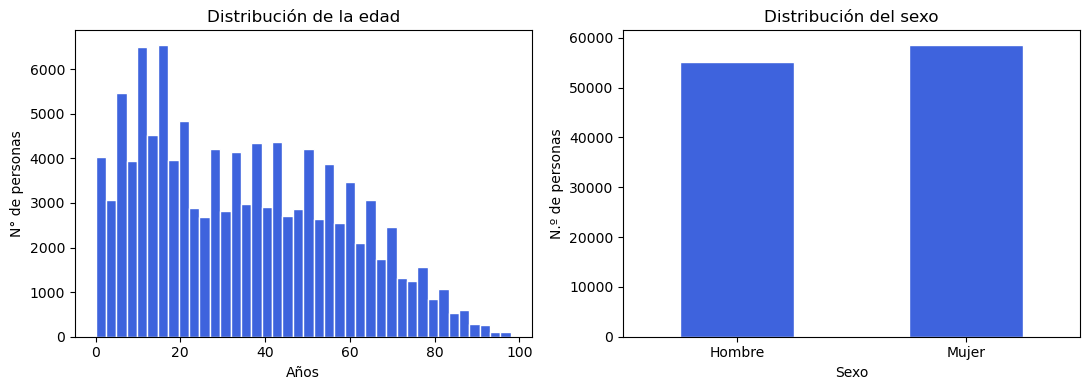

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(base["P208A"], bins=40, color="#3E63DD", edgecolor="white")
axes[0].set_title("Distribución de la edad")
axes[0].set_xlabel("Años")
axes[0].set_ylabel("N° de personas")

# Obtener las etiquetas de los valores de P207
etiquetas = meta.variable_value_labels.get("P207", {})

# Calcular frecuencias y ordenar por código
frecuencias = base["P207"].value_counts().sort_index()

# Reemplazar los códigos por sus etiquetas
frecuencias.index = [
    etiquetas.get(int(codigo), str(codigo))
    for codigo in frecuencias.index
]

# Crear el gráfico
frecuencias.plot(
    kind="bar",
    color="#3E63DD",
    edgecolor="white",
    ax=axes[1]
)

axes[1].set_title("Distribución del sexo")
axes[1].set_xlabel("Sexo")
axes[1].set_ylabel("N.º de personas")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


En el gráfico izquierdo, se observa una distribución de las edades que presenta una mayor concentración de observaciones en las edades jóvenes, especialmente durante la adolescencia y los primeros años de la adultez. Asimismo, se observa que la frecuencia disminuye progresivamente en las edades más avanzadas, con una menor representación de personas de 70 años a más.
En el gráfico derecho, se observa una distribución relativamente equilibrada, donde la cantidad de observaciones de mujeres es ligeramente superior a la de los hombres.

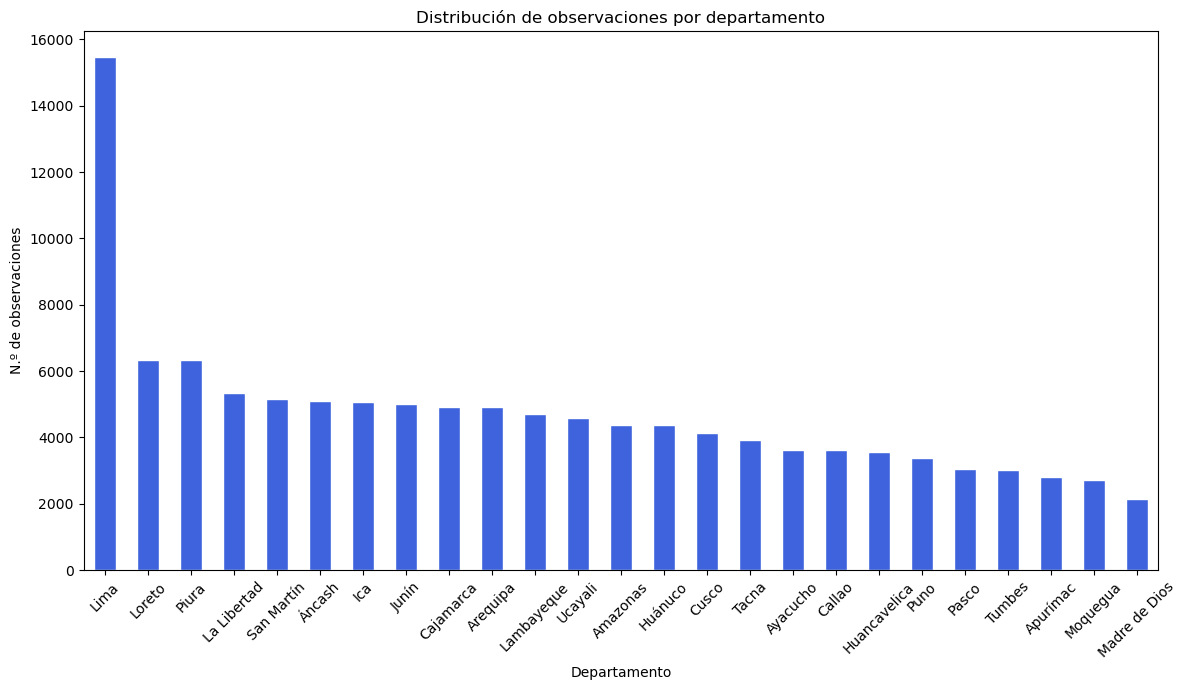

In [36]:
# 1. Convertir UBIGEO a texto para conservar los ceros iniciales
base["UBIGEO"] = (
    base["UBIGEO"]
    .astype("Int64")
    .astype("string")
    .str.zfill(6)
)

# 2. Extraer el código del departamento
base["COD_DEP"] = base["UBIGEO"].str[:2]

# 3. Diccionario de departamentos del Perú
departamentos = {
    "01": "Amazonas",
    "02": "Áncash",
    "03": "Apurímac",
    "04": "Arequipa",
    "05": "Ayacucho",
    "06": "Cajamarca",
    "07": "Callao",
    "08": "Cusco",
    "09": "Huancavelica",
    "10": "Huánuco",
    "11": "Ica",
    "12": "Junín",
    "13": "La Libertad",
    "14": "Lambayeque",
    "15": "Lima",
    "16": "Loreto",
    "17": "Madre de Dios",
    "18": "Moquegua",
    "19": "Pasco",
    "20": "Piura",
    "21": "Puno",
    "22": "San Martín",
    "23": "Tacna",
    "24": "Tumbes",
    "25": "Ucayali"
}

# 4. Asignar el nombre del departamento
base["DEPARTAMENTO"] = base["COD_DEP"].map(departamentos)

# 5. Calcular la frecuencia por departamento
frecuencias = base["DEPARTAMENTO"].value_counts().sort_values(
    ascending=False
)

# 6. Graficar la distribución
fig, ax = plt.subplots(figsize=(12, 7))

frecuencias.plot(
    kind="bar",
    color="#3E63DD",
    edgecolor="white",
    ax=ax
)

ax.set_title("Distribución de observaciones por departamento")
ax.set_xlabel("Departamento")
ax.set_ylabel("N.º de observaciones")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

En el gráfico superior se observa una mayor frecuencia de observaciones del departamento de Lima, a diferencia de los demás departamentos. Por la cantidad de observaciones por departamento se observa que se cumple con un valor aceptable de representatividad.